# Helios Renderer Multi-DAP Comparison & Performance Benchmark (DAP 10, 50, 90)

This notebook evaluates the differentiable PyTorch renderer (`HeliosPyTorchRenderer`, `HeliosPlantGeometryBuilder`, `PlantOrganArray`) across multiple plant growth stages (**DAP 10**, **DAP 50**, and **DAP 90**).

**Evaluated Growth Stages:**
- **DAP 10** (Early vegetative stage, ~80 organ nodes): Small canopy, main stem, and primary leaves.
- **DAP 50** (Mid-season canopy stage, ~1,095 organ nodes): Dense branching canopy and extensive foliage.
- **DAP 90** (Full maturity stage, ~1,570 organ nodes): Full plant architecture with branches, leaves, flowers, and pods.

**Panels per DAP (left to right):**
1. **Helios ref** – C++ OpenGL visualizer reference image
2. **black bg** – Python differentiable renderer, black background (`background="black"`)
3. **ground bg** – Python differentiable renderer, Helios-like soil background (`background="ground"`)
4. **Typed OrganArray** – Reconstructed geometry from typed `PlantOrganArray` ((N, 40) representation)
5. **Legacy OrganArray** – Reconstructed geometry from legacy `PlantOrganArray` ((N, 94) representation)

In [1]:
import os
import sys
import time
import math
import json
import subprocess
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# skimage for SSIM
from skimage.metrics import structural_similarity as ssim

# Ensure repo root is on path
repo_root = "/home/lion397/codes/image-to-l-system"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from diffusion_based.models.plant_organ_array import PlantOrganArray
from diffusion_based.models.helios_pytorch_geometry import HeliosPlantGeometryBuilder
from diffusion_based.models.helios_pytorch_renderer import HeliosPyTorchRenderer
from diffusion_based.models.helios_xml_parser import HeliosXMLParser

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA device: NVIDIA RTX 6000 Ada Generation


## 1. Multi-DAP Paths & Parameters (DAP 10, 50, 90)

In [2]:
DAP_LIST = [10, 50, 90]
dapcmp_dir = os.path.join(repo_root, "Digital-Crops", "projects", "syntheticdata_generation", "build", "dapcmp")

DAP_SAMPLES = {
    10: {
        "xml": os.path.join(dapcmp_dir, "d10", "d10_all_0000_plant_0000.xml"),
        "ref": os.path.join(dapcmp_dir, "d10", "d10_all_0000_vis.jpeg"),
    },
    50: {
        "xml": os.path.join(dapcmp_dir, "d50", "d50_all_0000_plant_0000.xml"),
        "ref": os.path.join(dapcmp_dir, "d50", "d50_all_0000_vis.jpeg"),
    },
    90: {
        "xml": os.path.join(dapcmp_dir, "d90", "d90_all_0000_plant_0000.xml"),
        "ref": os.path.join(dapcmp_dir, "d90", "d90_all_0000_vis.jpeg"),
    },
}

IMAGE_SIZE = 256
CAMERA_HEIGHT = 1.0
AZIMUTH_DEG = 0.0

for dap, paths in DAP_SAMPLES.items():
    assert os.path.exists(paths["xml"]), f"DAP {dap} XML not found: {paths['xml']}"
    assert os.path.exists(paths["ref"]), f"DAP {dap} Ref image not found: {paths['ref']}"
    print(f"DAP {dap:2d} -> XML: {paths['xml']}")
    print(f"         Ref Image: {paths['ref']}")

DAP 10 -> XML: /home/lion397/codes/image-to-l-system/Digital-Crops/projects/syntheticdata_generation/build/dapcmp/d10/d10_all_0000_plant_0000.xml
         Ref Image: /home/lion397/codes/image-to-l-system/Digital-Crops/projects/syntheticdata_generation/build/dapcmp/d10/d10_all_0000_vis.jpeg
DAP 50 -> XML: /home/lion397/codes/image-to-l-system/Digital-Crops/projects/syntheticdata_generation/build/dapcmp/d50/d50_all_0000_plant_0000.xml
         Ref Image: /home/lion397/codes/image-to-l-system/Digital-Crops/projects/syntheticdata_generation/build/dapcmp/d50/d50_all_0000_vis.jpeg
DAP 90 -> XML: /home/lion397/codes/image-to-l-system/Digital-Crops/projects/syntheticdata_generation/build/dapcmp/d90/d90_all_0000_plant_0000.xml
         Ref Image: /home/lion397/codes/image-to-l-system/Digital-Crops/projects/syntheticdata_generation/build/dapcmp/d90/d90_all_0000_vis.jpeg


## 2. Load Reference Images

In [3]:
ref_images = {}
for dap, paths in DAP_SAMPLES.items():
    img = Image.open(paths["ref"]).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)
    ref_images[dap] = np.array(img, dtype=np.float32) / 255.0
    print(f"DAP {dap:2d} reference image size: {img.size}, range: [{ref_images[dap].min():.3f}, {ref_images[dap].max():.3f}]")

DAP 10 reference image size: (256, 256), range: [0.000, 1.000]
DAP 50 reference image size: (256, 256), range: [0.000, 1.000]
DAP 90 reference image size: (256, 256), range: [0.000, 1.000]


## 3. Initialise Renderer

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
renderer = HeliosPyTorchRenderer(image_size=IMAGE_SIZE)
geo_builder = HeliosPlantGeometryBuilder()
print(f"PyTorch renderer initialized on device: {device}")

PyTorch renderer initialized on device: cuda


## 4. Render All DAPs (DAP 10, 50, 90)

In [5]:
renders = {}

for dap, paths in DAP_SAMPLES.items():
    xml_file = paths["xml"]
    oa_typed = PlantOrganArray.from_xml_file_typed(xml_file)
    oa_legacy = PlantOrganArray.from_xml_file(xml_file)
    
    print(f"DAP {dap:2d}: Typed nodes={oa_typed.num_nodes}, Legacy nodes={oa_legacy.num_nodes}")
    
    with torch.no_grad():
        # Typed renderings
        img_typed_black_t = renderer.render_organ_array(
            oa_typed, azimuth_deg=AZIMUTH_DEG, elevation_deg=90.0, camera_height=CAMERA_HEIGHT, background="black", device=device, focus_plant=True
        )
        img_typed_ground_t = renderer.render_organ_array(
            oa_typed, azimuth_deg=AZIMUTH_DEG, elevation_deg=90.0, camera_height=CAMERA_HEIGHT, background="ground", device=device, focus_plant=True
        )
        
        # Legacy renderings
        img_legacy_black_t = renderer.render_organ_array(
            oa_legacy, azimuth_deg=AZIMUTH_DEG, elevation_deg=90.0, camera_height=CAMERA_HEIGHT, background="black", device=device, focus_plant=True
        )
        img_legacy_ground_t = renderer.render_organ_array(
            oa_legacy, azimuth_deg=AZIMUTH_DEG, elevation_deg=90.0, camera_height=CAMERA_HEIGHT, background="ground", device=device, focus_plant=True
        )
        
    renders[dap] = {
        "typed_black": img_typed_black_t.permute(1, 2, 0).cpu().numpy(),
        "typed_ground": img_typed_ground_t.permute(1, 2, 0).cpu().numpy(),
        "legacy_black": img_legacy_black_t.permute(1, 2, 0).cpu().numpy(),
        "legacy_ground": img_legacy_ground_t.permute(1, 2, 0).cpu().numpy(),
        "num_nodes": oa_typed.num_nodes,
    }

print("Multi-DAP renderings completed.")

DAP 10: Typed nodes=80, Legacy nodes=11
DAP 50: Typed nodes=1095, Legacy nodes=155
DAP 90: Typed nodes=1570, Legacy nodes=201
Multi-DAP renderings completed.


## 5. Compute Metrics (MAE, SSIM, Mask IoU)

In [6]:
def compute_metrics(ref, pred):
    mae = float(np.mean(np.abs(ref - pred)))
    ssim_val = float(ssim(ref, pred, channel_axis=-1, data_range=1.0))
    return mae, ssim_val

def compute_mask_iou(ref, pred, ref_thresh=0.65, pred_thresh=0.08):
    ref_gray = ref.mean(axis=-1)
    pred_gray = pred.mean(axis=-1)
    ref_mask = ref_gray < ref_thresh
    pred_mask = pred_gray > pred_thresh
    inter = np.logical_and(ref_mask, pred_mask).sum()
    union = np.logical_or(ref_mask, pred_mask).sum()
    iou = float(inter) / float(union) if union > 0 else 0.0
    prec = float(inter) / float(pred_mask.sum()) if pred_mask.sum() > 0 else 0.0
    rec = float(inter) / float(ref_mask.sum()) if ref_mask.sum() > 0 else 0.0
    return iou, prec, rec

multi_dap_results = {}

for dap in DAP_LIST:
    ref_np = ref_images[dap]
    r = renders[dap]
    
    mae_tb, ssim_tb = compute_metrics(ref_np, r["typed_black"])
    iou_tb, prec_tb, rec_tb = compute_mask_iou(ref_np, r["typed_black"])
    
    mae_tg, ssim_tg = compute_metrics(ref_np, r["typed_ground"])
    iou_tg, prec_tg, rec_tg = compute_mask_iou(ref_np, r["typed_ground"])
    
    multi_dap_results[f"DAP {dap} (black bg)"] = {"Nodes": r["num_nodes"], "MAE": mae_tb, "SSIM": ssim_tb, "IoU": iou_tb, "Precision": prec_tb, "Recall": rec_tb}
    multi_dap_results[f"DAP {dap} (ground bg)"] = {"Nodes": r["num_nodes"], "MAE": mae_tg, "SSIM": ssim_tg, "IoU": iou_tg, "Precision": prec_tg, "Recall": rec_tg}

import pandas as pd
df_res = pd.DataFrame.from_dict(multi_dap_results, orient="index")
print("─" * 80)
print(df_res[["Nodes", "MAE", "SSIM", "IoU", "Precision", "Recall"]].round(3).to_string())
print("─" * 80)

────────────────────────────────────────────────────────────────────────────────
                    Nodes    MAE   SSIM    IoU  Precision  Recall
DAP 10 (black bg)      80  0.399  0.084  0.421      0.950   0.430
DAP 10 (ground bg)     80  0.160  0.244  0.837      0.837   1.000
DAP 50 (black bg)    1095  0.306  0.074  0.583      0.959   0.598
DAP 50 (ground bg)   1095  0.158  0.122  0.923      0.923   1.000
DAP 90 (black bg)    1570  0.358  0.035  0.460      0.916   0.480
DAP 90 (ground bg)   1570  0.172  0.113  0.894      0.898   0.996
────────────────────────────────────────────────────────────────────────────────


## 6. Multi-DAP Panel Comparison Figure (3 DAPs x 5 Panels)

Rows: DAP 10, DAP 50, DAP 90.
Columns: Helios ref | black bg | ground bg | Typed OrganArray | Legacy OrganArray.

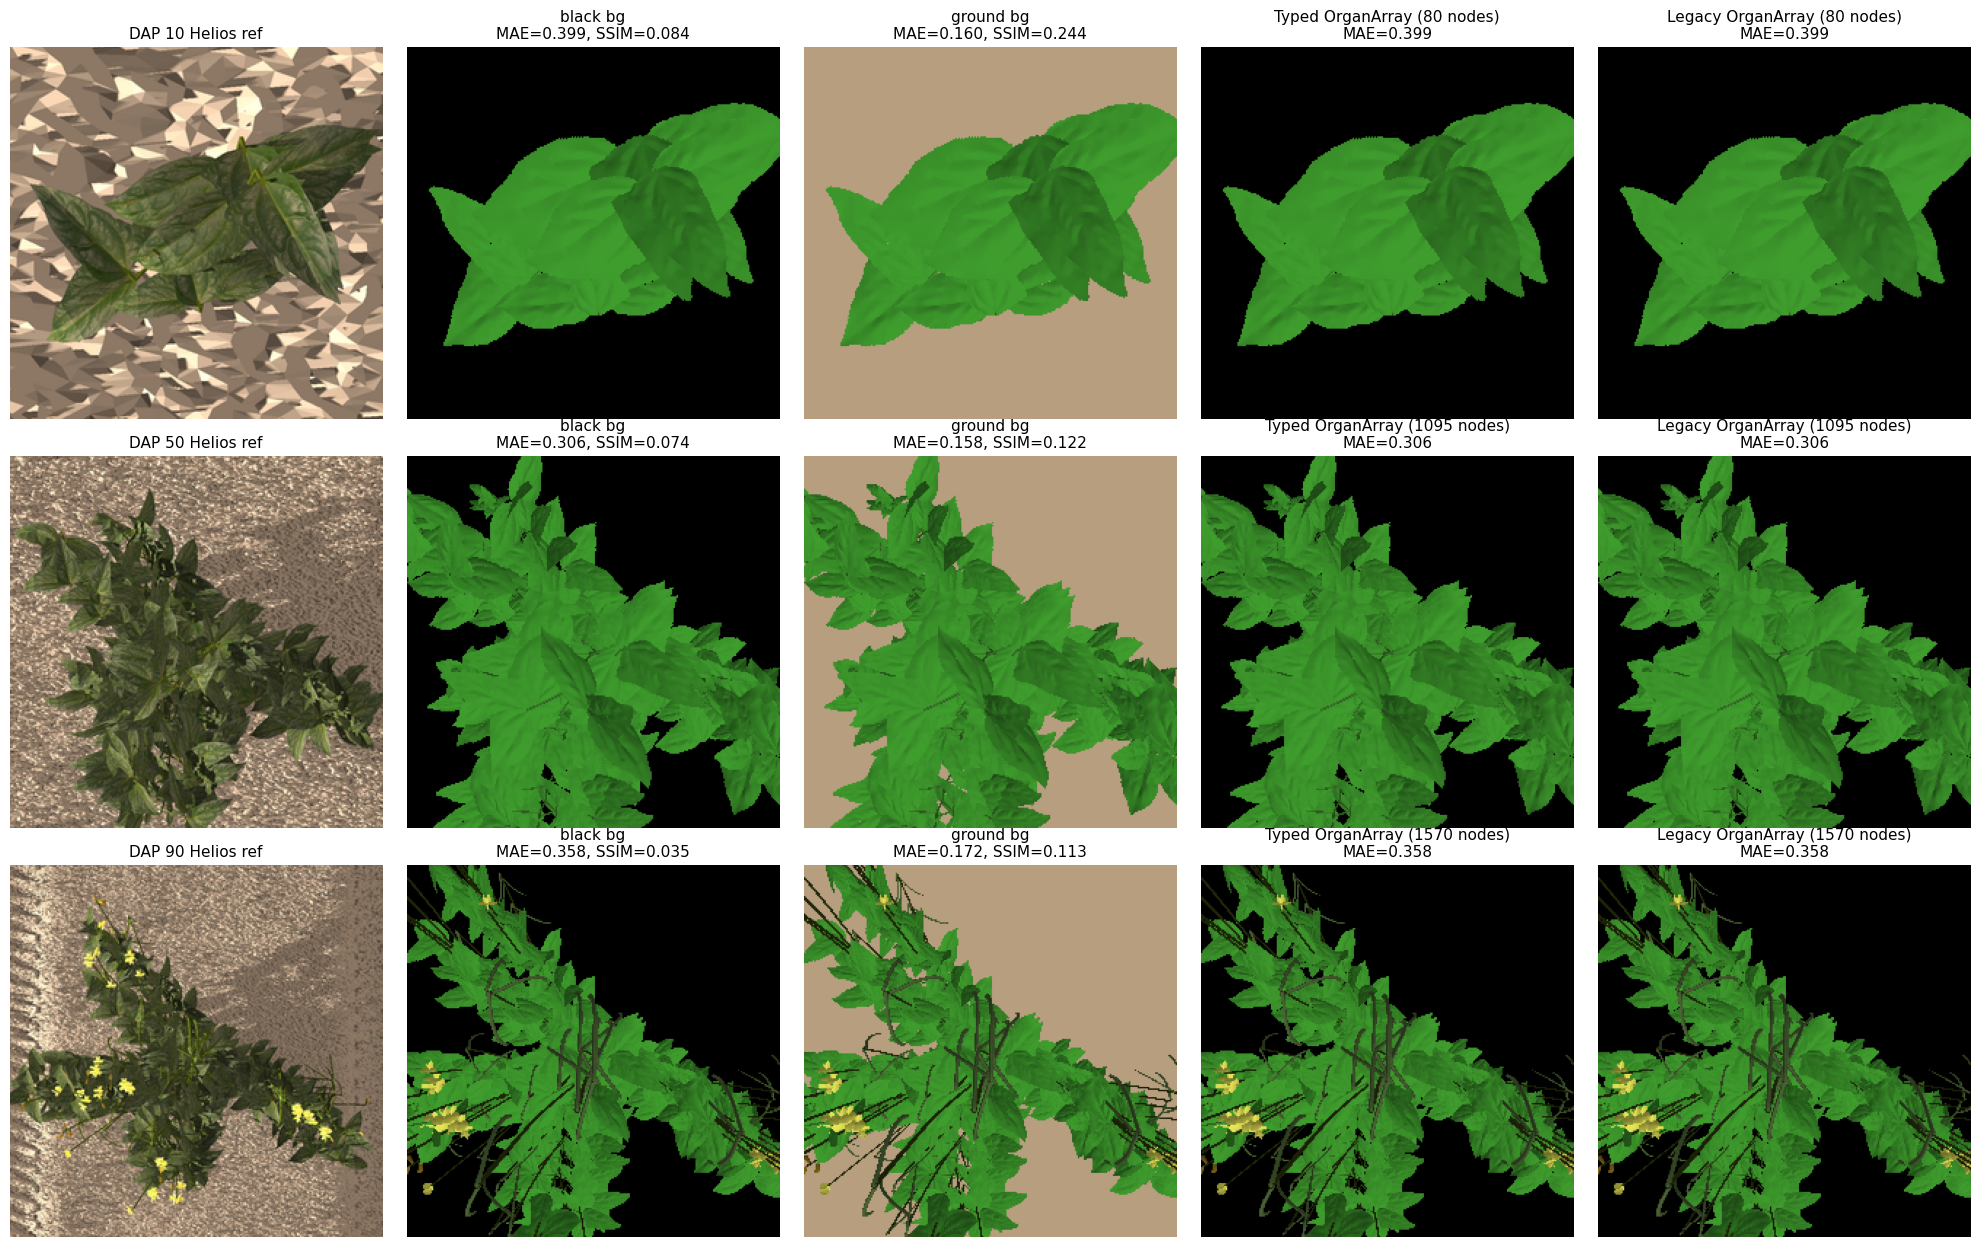

Saved: notebooks/render_comparison_multi_dap_5panel.png


In [7]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12.5))

for row_idx, dap in enumerate(DAP_LIST):
    ref_np = ref_images[dap]
    r = renders[dap]
    
    mae_tb = multi_dap_results[f"DAP {dap} (black bg)"]["MAE"]
    ssim_tb = multi_dap_results[f"DAP {dap} (black bg)"]["SSIM"]
    mae_tg = multi_dap_results[f"DAP {dap} (ground bg)"]["MAE"]
    ssim_tg = multi_dap_results[f"DAP {dap} (ground bg)"]["SSIM"]
    
    row_imgs = [
        ref_np,
        r["typed_black"],
        r["typed_ground"],
        r["typed_black"],
        r["legacy_black"],
    ]
    row_titles = [
        f"DAP {dap} Helios ref",
        f"black bg\nMAE={mae_tb:.3f}, SSIM={ssim_tb:.3f}",
        f"ground bg\nMAE={mae_tg:.3f}, SSIM={ssim_tg:.3f}",
        f"Typed OrganArray ({r['num_nodes']} nodes)\nMAE={mae_tb:.3f}",
        f"Legacy OrganArray ({r['num_nodes']} nodes)\nMAE={mae_tb:.3f}",
    ]
    
    for col_idx, (img, title) in enumerate(zip(row_imgs, row_titles)):
        ax = axes[row_idx, col_idx]
        ax.imshow(np.clip(img, 0, 1))
        ax.set_title(title, fontsize=11)
        ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(repo_root, "notebooks", "render_comparison_multi_dap_5panel.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: notebooks/render_comparison_multi_dap_5panel.png")

## 7. Multi-View Stability (Azimuth Orbit Sweep at 45° Elevation)

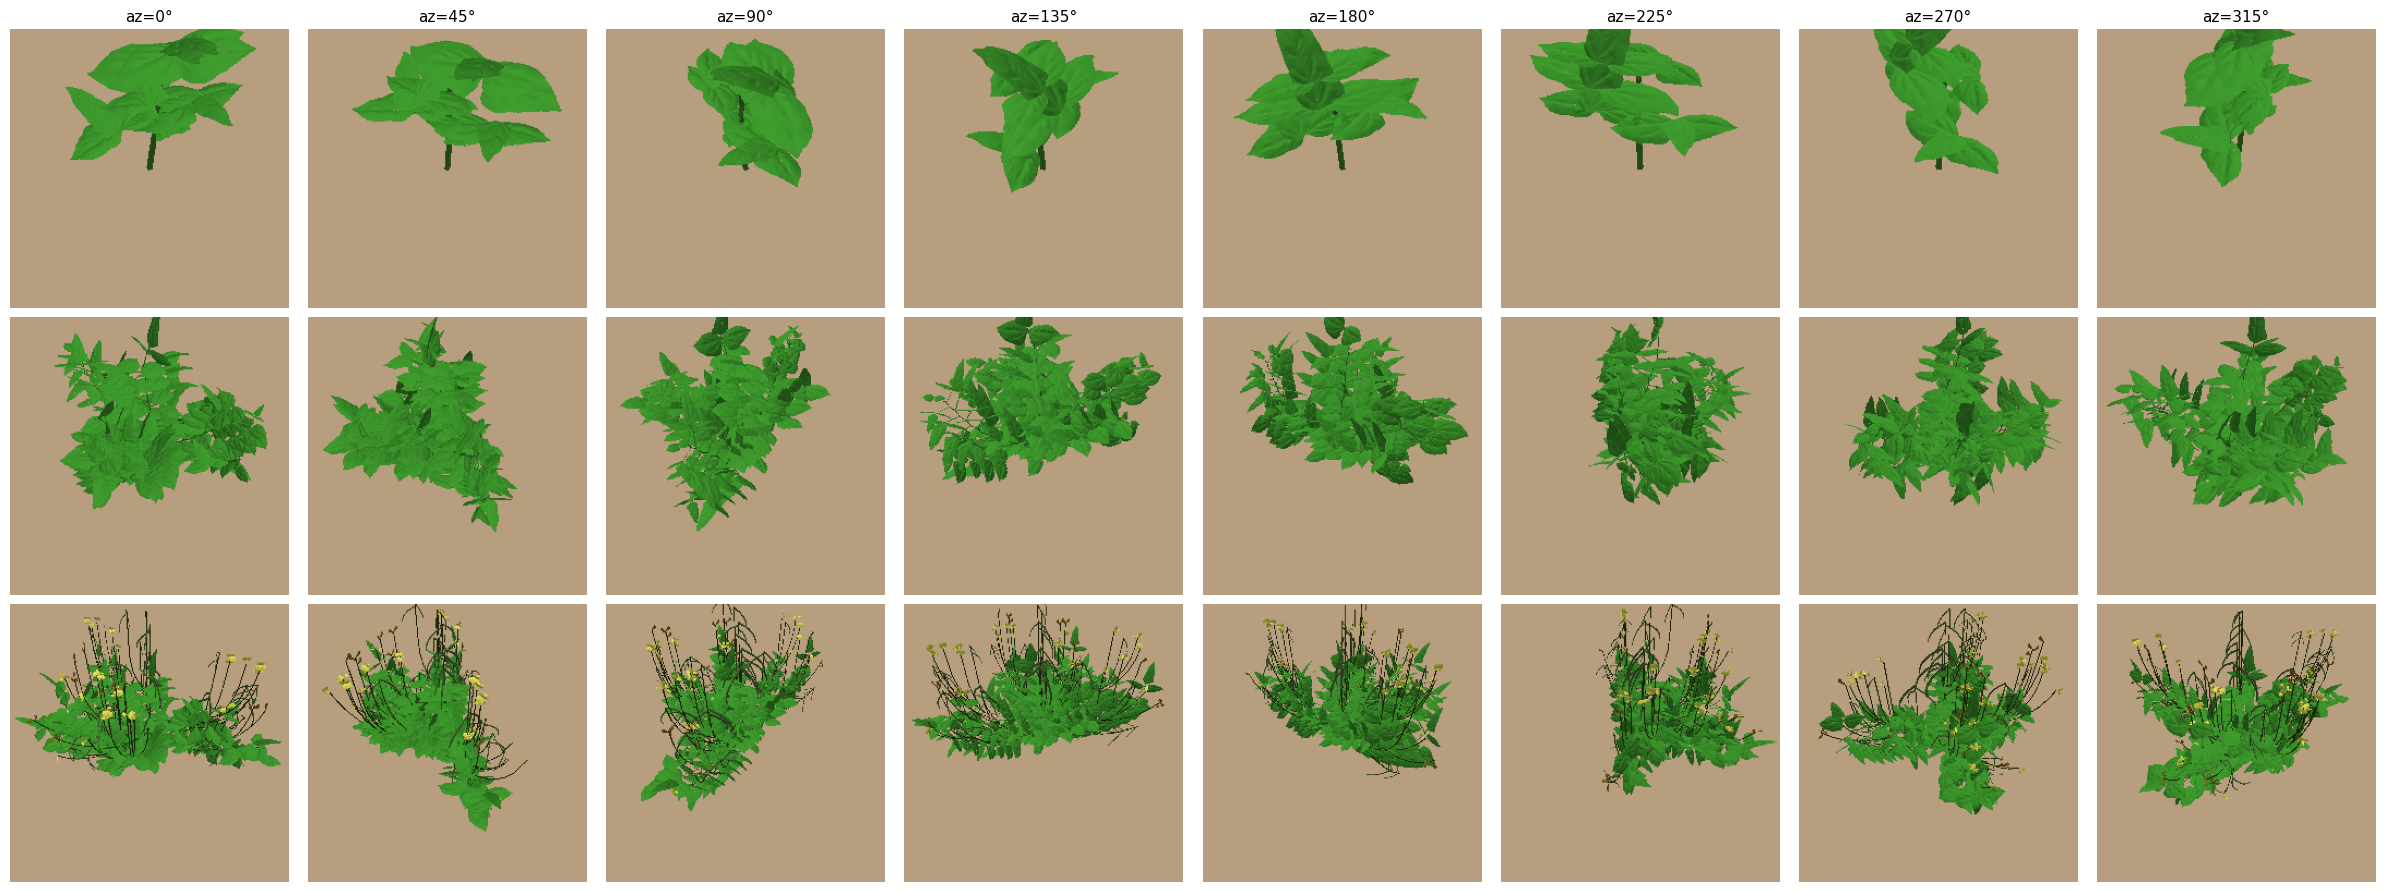

Saved: notebooks/azimuth_grid_multi_dap.png


In [8]:
azimuths = [0, 45, 90, 135, 180, 225, 270, 315]
fig, axes = plt.subplots(3, 8, figsize=(24, 9))

for row_idx, dap in enumerate(DAP_LIST):
    xml_file = DAP_SAMPLES[dap]["xml"]
    oa_typed = PlantOrganArray.from_xml_file_typed(xml_file)
    
    for col_idx, az in enumerate(azimuths):
        ax = axes[row_idx, col_idx]
        with torch.no_grad():
            img_az_t = renderer.render_organ_array(
                oa_typed,
                azimuth_deg=float(az),
                elevation_deg=45.0,
                camera_height=CAMERA_HEIGHT,
                background="ground",
                device=device,
                focus_plant=True,
            )
        img_az = img_az_t.permute(1, 2, 0).cpu().numpy()
        ax.imshow(np.clip(img_az, 0, 1))
        if row_idx == 0:
            ax.set_title(f"az={az}°", fontsize=11)
        if col_idx == 0:
            ax.set_ylabel(f"DAP {dap}", fontsize=12, fontweight="bold")
        ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(repo_root, "notebooks", "azimuth_grid_multi_dap.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: notebooks/azimuth_grid_multi_dap.png")

## 8. Performance & Latency Benchmark Across DAP 10, 50, 90 (Helios C++ vs PyTorch Renderer)

--- Multi-DAP Performance Benchmark ---


DAP 10 (  80 nodes) -> C++: 6150.6ms (0.16 FPS) | PyTorch: 49.8ms (20.1 FPS) | Speedup: 123.6x
DAP 50 (1095 nodes) -> C++: 8064.5ms (0.12 FPS) | PyTorch: 660.2ms (1.5 FPS) | Speedup: 12.2x
DAP 90 (1570 nodes) -> C++: 12173.5ms (0.08 FPS) | PyTorch: 1197.1ms (0.8 FPS) | Speedup: 10.2x
─────────────────────────────────────────────────────────────────────────────────────
DAP    Nodes       C++ Time (ms)  PyTorch Time (ms)    PyTorch FPS      Speedup
─────────────────────────────────────────────────────────────────────────────────────
10     80                6150.63              49.75           20.1       123.6x
50     1095              8064.47             660.24            1.5        12.2x
90     1570             12173.46            1197.15            0.8        10.2x
─────────────────────────────────────────────────────────────────────────────────────


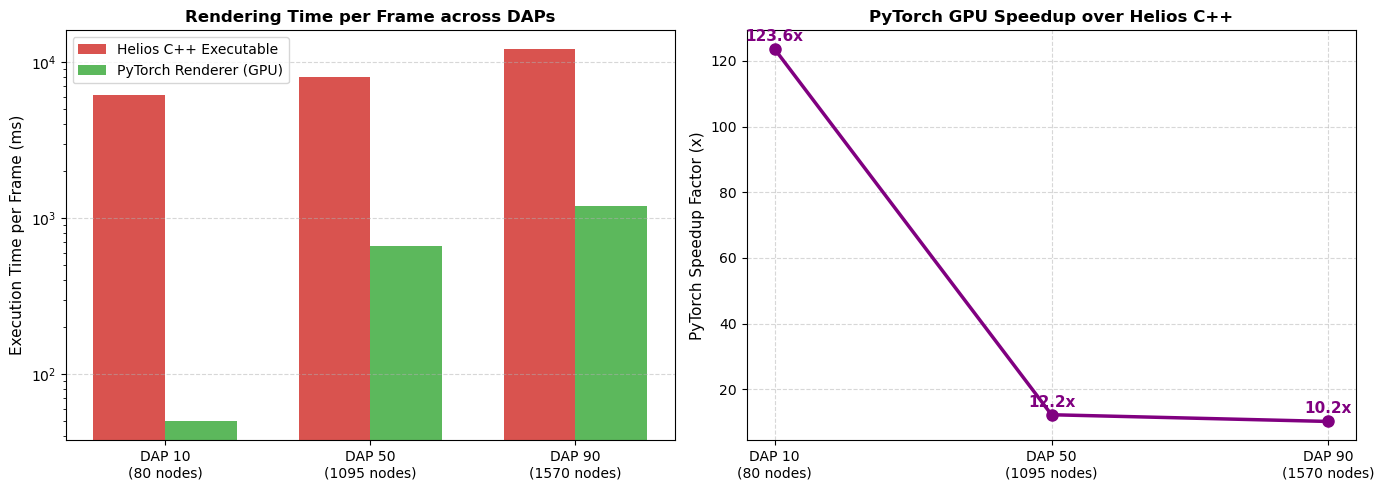

Saved: notebooks/multi_dap_rendering_time_benchmark.png


In [9]:
import subprocess
import json

print("--- Multi-DAP Performance Benchmark ---")
main_binary = os.path.join(repo_root, "Digital-Crops", "projects", "syntheticdata_generation", "build", "main")
base_params_file = os.path.join(repo_root, "Digital-Crops", "projects", "syntheticdata_generation", "params.json")

bench_results = {}
env = os.environ.copy()
if "DISPLAY" not in env:
    env["DISPLAY"] = ":1.0"

for dap in DAP_LIST:
    xml_file = DAP_SAMPLES[dap]["xml"]
    oa_typed = PlantOrganArray.from_xml_file_typed(xml_file)
    num_nodes = oa_typed.num_nodes
    
    # 1. Helios C++ timing
    with open(base_params_file, "r") as f:
        bench_params = json.load(f)
    bench_params.setdefault("camera", {}).setdefault("positioning", {})["azimuth_angle"] = 0.0
    bench_params["camera"]["positioning"]["camera_height"] = 1.0
    bench_params["camera"]["positioning"]["focusing_plants"] = True
    bench_params.setdefault("metadata", {})["dap"] = dap
    bench_params["field"]["plots"][0]["plants"][0]["xml"] = xml_file
    
    bench_dir = os.path.join(repo_root, "notebooks", "output_dap10_stability")
    tmp_params_path = os.path.join(bench_dir, f"bench_params_dap{dap}.json")
    with open(tmp_params_path, "w") as f:
        json.dump(bench_params, f, indent=2)
        
    cmd = [
        main_binary,
        "--renderer", "vis",
        "--focus-plant",
        "-n", f"bench_cpp_dap{dap}",
        "--dap", str(dap),
        "-s", "42",
        "--output", bench_dir,
        "-f", tmp_params_path,
    ]
    
    # Warmup C++
    subprocess.run(cmd, cwd=os.path.dirname(main_binary), env=env, capture_output=True, text=True)
    
    cpp_times = []
    for _ in range(3):
        t0 = time.perf_counter()
        subprocess.run(cmd, cwd=os.path.dirname(main_binary), env=env, capture_output=True, text=True)
        t1 = time.perf_counter()
        cpp_times.append(t1 - t0)
    cpp_mean_ms = float(np.mean(cpp_times) * 1000.0)
    
    # 2. PyTorch timing
    for _ in range(10):
        with torch.no_grad():
            renderer.render_organ_array(oa_typed, device=device, background="ground")
    if device.type == "cuda":
        torch.cuda.synchronize()
        
    py_times = []
    for _ in range(30):
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            renderer.render_organ_array(oa_typed, device=device, background="ground")
        if device.type == "cuda":
            torch.cuda.synchronize()
        t1 = time.perf_counter()
        py_times.append(t1 - t0)
    py_mean_ms = float(np.mean(py_times) * 1000.0)
    
    bench_results[dap] = {
        "nodes": num_nodes,
        "cpp_ms": cpp_mean_ms,
        "cpp_fps": 1000.0 / cpp_mean_ms,
        "py_ms": py_mean_ms,
        "py_fps": 1000.0 / py_mean_ms,
        "speedup": cpp_mean_ms / py_mean_ms,
    }
    print(f"DAP {dap:2d} ({num_nodes:4d} nodes) -> C++: {cpp_mean_ms:.1f}ms ({1000.0/cpp_mean_ms:.2f} FPS) | PyTorch: {py_mean_ms:.1f}ms ({1000.0/py_mean_ms:.1f} FPS) | Speedup: {cpp_mean_ms/py_mean_ms:.1f}x")

# Summary Table
print("─" * 85)
print(f"{'DAP':<6} {'Nodes':<8} {'C++ Time (ms)':>16} {'PyTorch Time (ms)':>18} {'PyTorch FPS':>14} {'Speedup':>12}")
print("─" * 85)
for dap in DAP_LIST:
    b = bench_results[dap]
    print(f"{dap:<6} {b['nodes']:<8} {b['cpp_ms']:>16.2f} {b['py_ms']:>18.2f} {b['py_fps']:>14.1f} {b['speedup']:>11.1f}x")
print("─" * 85)

# Plot benchmark comparison curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x_daps = [f"DAP {d}\n({bench_results[d]['nodes']} nodes)" for d in DAP_LIST]
cpp_ms_vals = [bench_results[d]["cpp_ms"] for d in DAP_LIST]
py_ms_vals = [bench_results[d]["py_ms"] for d in DAP_LIST]
speedup_vals = [bench_results[d]["speedup"] for d in DAP_LIST]

width = 0.35
x_indices = np.arange(len(DAP_LIST))

ax1.bar(x_indices - width/2, cpp_ms_vals, width, label="Helios C++ Executable", color="#d9534f")
ax1.bar(x_indices + width/2, py_ms_vals, width, label="PyTorch Renderer (GPU)", color="#5cb85c")
ax1.set_ylabel("Execution Time per Frame (ms)", fontsize=11)
ax1.set_xticks(x_indices)
ax1.set_xticklabels(x_daps, fontsize=10)
ax1.set_title("Rendering Time per Frame across DAPs", fontsize=12, fontweight="bold")
ax1.set_yscale("log")
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.legend()

ax2.plot(x_indices, speedup_vals, marker="o", linewidth=2.5, color="purple", markersize=8)
ax2.set_ylabel("PyTorch Speedup Factor (x)", fontsize=11)
ax2.set_xticks(x_indices)
ax2.set_xticklabels(x_daps, fontsize=10)
ax2.set_title("PyTorch GPU Speedup over Helios C++", fontsize=12, fontweight="bold")
ax2.grid(True, linestyle="--", alpha=0.5)
for i, sp in enumerate(speedup_vals):
    ax2.text(i, sp + max(speedup_vals)*0.02, f"{sp:.1f}x", ha="center", fontsize=11, fontweight="bold", color="purple")

plt.tight_layout()
plt.savefig(os.path.join(repo_root, "notebooks", "multi_dap_rendering_time_benchmark.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: notebooks/multi_dap_rendering_time_benchmark.png")